<a href="https://colab.research.google.com/github/MrSilva-HR/ProjectsHR/blob/main/rede_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instala a biblioteca Ultralytics (necessária para rodar o modelo)
print("1. Instalando Ultralytics...")
!pip install ultralytics -q

# Importa as bibliotecas necessárias
from ultralytics import YOLO
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

print("Setup concluído.")


1. Instalando Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup concluído.


2. Carregando modelo pré-treinado (Simulação do seu 'best.pt')...
3. Faça o upload de uma imagem de teste (PNG ou JPG) para detecção.


Saving muichiro-appreciation-v0-gxv0j195bnnc1.jpg to muichiro-appreciation-v0-gxv0j195bnnc1.jpg

4. Processando imagem: muichiro-appreciation-v0-gxv0j195bnnc1.jpg

image 1/1 /content/muichiro-appreciation-v0-gxv0j195bnnc1.jpg: 640x640 1 person, 408.0ms
Speed: 15.9ms preprocess, 408.0ms inference, 32.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
✅ Detecção concluída. Resultado salvo em: /content/runs/detect/predict/muichiro-appreciation-v0-gxv0j195bnnc1.jpg

--- IMAGEM COM DETECÇÕES ---


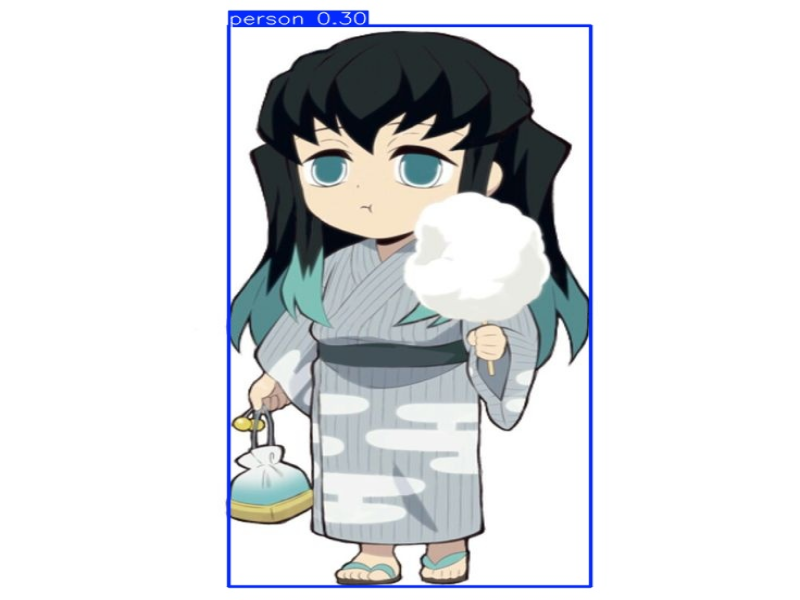


Baixando imagem com detecções...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
def simular_uso_modelo():
    """
    Simula o uso de um modelo treinado (inferência)
    usando um modelo YOLOv8 pré-treinado no COCO.
    """

    print("2. Carregando modelo pré-treinado (Simulação do seu 'best.pt')...")
    # Carregamos um modelo pré-treinado que simula o seu modelo final.
    # Se você tivesse o 'best.pt' do seu treinamento, usaria: model = YOLO('/caminho/para/seu/best.pt')
    model = YOLO('yolov8n.pt') # YOLOv8 Nano pré-treinado no COCO

    print("3. Faça o upload de uma imagem de teste (PNG ou JPG) para detecção.")
    uploaded = files.upload()

    if not uploaded:
        print("Nenhuma imagem enviada. Simulação cancelada.")
        return

    image_filename = list(uploaded.keys())[0]

    print(f"\n4. Processando imagem: {image_filename}")

    # Executa a inferência (detecção)
    # save=True salva a imagem com as caixas delimitadoras no disco
    results = model.predict(source=image_filename, save=True, conf=0.25)

    # 5. Localiza o resultado (o Ultralytics salva em runs/detect/predictX)
    # Acessa o caminho do primeiro resultado salvo
    result_path = results[0].save_dir

    # Constrói o caminho completo para a imagem processada
    processed_image_path = f"{result_path}/{image_filename}"

    print(f"✅ Detecção concluída. Resultado salvo em: {processed_image_path}")

    # 6. Exibe a imagem processada no Colab para visualização
    try:
        img = cv2.imread(processed_image_path)
        if img is not None:
            # Redimensiona para caber na tela do Colab
            img_resized = cv2.resize(img, (800, 600), interpolation=cv2.INTER_AREA)
            print("\n--- IMAGEM COM DETECÇÕES ---")
            cv2_imshow(img_resized) # Função específica do Colab para mostrar imagem CV2

            # Oferece o download da imagem processada
            print("\nBaixando imagem com detecções...")
            files.download(processed_image_path)
        else:
            print("Erro ao carregar a imagem processada.")

    except Exception as e:
        print(f"Erro na visualização/download: {e}")

# --- Executar a Simulação ---
simular_uso_modelo()

## Documentação do Projeto

Este projeto utiliza as seguintes bibliotecas e ferramentas para realizar a detecção de objetos:

### 1. Ultralytics YOLO

*   **Propósito**: A biblioteca Ultralytics é a base deste projeto, fornecendo uma implementação fácil de usar e de alta performance do modelo YOLO (You Only Look Once).
*   **Uso no Projeto**: Ela é usada para carregar o modelo pré-treinado (`yolov8n.pt` neste caso, simulando seu `best.pt`) e executar a inferência (detecção de objetos) em imagens.

### 2. `google.colab.files`

*   **Propósito**: Esta biblioteca é específica para ambientes Google Colab e permite interagir com o sistema de arquivos local do usuário diretamente do notebook.
*   **Uso no Projeto**: Utilizada para facilitar o upload de imagens de teste pelo usuário e o download das imagens processadas com as detecções.

### 3. `cv2` (OpenCV)

*   **Propósito**: OpenCV (Open Source Computer Vision Library) é uma biblioteca amplamente utilizada para tarefas de visão computacional e processamento de imagens.
*   **Uso no Projeto**: Empregada para ler (`cv2.imread`), redimensionar (`cv2.resize`) e exibir (`cv2_imshow` - uma função otimizada para Colab) as imagens, tanto as originais quanto as processadas com as detecções.

### 4. `numpy`

*   **Propósito**: NumPy é a biblioteca fundamental para computação numérica em Python, oferecendo suporte a arrays e matrizes de alta performance, além de funções matemáticas para operar sobre eles.
*   **Uso no Projeto**: Embora não explicitamente chamada para operações diretas no código principal de inferência, é uma dependência subjacente de bibliotecas como OpenCV, que manipulam dados de imagem como arrays NumPy.

## Utilidade da Rede YOLO (You Only Look Once)

**YOLO** (You Only Look Once) é uma família popular de modelos de detecção de objetos em tempo real que revolucionou a área de visão computacional por sua velocidade e precisão.

### Como Funciona?

Ao contrário de sistemas de detecção mais antigos que propõem regiões de interesse e depois classificam cada uma delas, o YOLO processa a imagem completa em uma única passagem através da rede neural. Ele divide a imagem em uma grade e, para cada célula da grade, prevê caixas delimitadoras (bounding boxes), uma pontuação de confiança para essas caixas e probabilidades de classe.

### Principais Vantagens:

1.  **Velocidade em Tempo Real**: É um dos detectores de objetos mais rápidos disponíveis, o que o torna ideal para aplicações que exigem processamento em tempo real, como direção autônoma, vigilância por vídeo e robótica.
2.  **Precisão**: Apesar de sua velocidade, o YOLO mantém uma alta precisão na detecção de uma ampla variedade de objetos.
3.  **Contexto Global**: Por analisar a imagem inteira de uma vez, o YOLO consegue capturar informações contextuais globais, o que ajuda a reduzir erros de fundo (falsos positivos) em comparação com métodos que analisam apenas partes da imagem.
4.  **Flexibilidade**: Existem diversas versões e tamanhos de modelos YOLO (YOLOv3, YOLOv5, YOLOv8, etc.), permitindo escolher um modelo que equilibre velocidade e precisão de acordo com as necessidades da aplicação.

### Uso no Projeto:

Neste notebook, um modelo YOLOv8 pré-treinado é utilizado para:

*   **Carregar um modelo existente (`yolov8n.pt`)**: Simula o carregamento de um modelo personalizado (`best.pt`) treinado para uma tarefa específica.
*   **Realizar Inferência**: Aplicar o modelo em uma imagem de teste para identificar e localizar objetos dentro dela, desenhando caixas delimitadoras e rótulos para cada objeto detectado.